<div style="display: flex; align-items: center; justify-content: center; flex-wrap: wrap;">
    <div style="flex: 1; max-width: 400px; display: flex; justify-content: center;">
        <img src="https://magic.novaims.unl.pt/media/1tdf2arr/ims25_horizontal__positivo_rgb.svg" style="max-width: 70%; height: auto; margin-top: 50px; margin-bottom: 50px;margin-left: 6rem;">
    </div>
    <div style="flex: 2; text-align: center; margin-top: 20px;margin-left: 6rem;">
        <div style="font-size: 28px; font-weight: bold; line-height: 1.2;">
            <span style="color: #FFCD41;">Thesis Project |</span> <span style="color: #F58228;">LLM-Powered Urban Exploration: A Framework for Adaptive Tourist and Mobility Route Planning</span>
        </div>
        <div style="font-size: 17px; font-weight: bold; margin-top: 10px;">
            2025 - 2026
        </div>
        <div style="font-size: 17px; font-weight: bold;">
            Master in Data Science and Advanced Analytics
        </div>
        <div style="margin-top: 20px;">
            <div>André Filipe Gomes Silvestre, 20240502</div>
        </div>
    </div>
</div>

<style>
@import url('https://fonts.cdnfonts.com/css/avenir-next-lt-pro?styles=29974');
</style>

<div style="background: linear-gradient(to right, #F58228, #FFCD41);
            padding: 15px; color: white; border-radius: 300px; text-align: center;">
    <center><h1 style="margin-left: 100px;margin-top: 10px; margin-bottom: 4px; color: white;
                       font-size: 32px; font-family: 'Avenir Next LT Pro', sans-serif;"><b>1 & 2 | Business & Data Understanding</b></h1></center>
</div>

<br><br>


## **📝 Notebook Overview**

This notebook analyzes datasets scraped from the **VisitLisbon** and **Dados.gov** websites. It includes data cleaning, exploratory data analysis (EDA), and visualizations to uncover insights about tourist attractions and public amenities in Lisbon.

<br><br>

In [1]:
# Install the required packages
# !pip install json pandas matplotlib seaborn tqdm requests

In [2]:
# Import necessary libraries
import re
import json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from tqdm import tqdm

%matplotlib inline

In [3]:
# Settings to customize plots
sns.set_theme(context='paper', style="white", font= 'Borna', rc={"figure.figsize":(48, 32)}, font_scale=1.5)

# Define a color palette based on the project colors (Orange/Yellow tones)
# #ff4011 (Red), #F58228 (Orange), #f6da00 (Yellow)
custom_palette = ['#ff4011', '#F58228', '#f6da00']
sns.set_palette(custom_palette)


In [4]:
# Load the JSON files
with open('events.json', 'r', encoding='utf-8') as f:
    events_data = json.load(f)

with open('places.json', 'r', encoding='utf-8') as f:
    places_data = json.load(f)

with open('lisbon_datasets.json', 'r', encoding='utf-8') as f:
    lisbon_datasets_original = json.load(f)
    
with open('lisbon_datasets_clean.json', 'r', encoding='utf-8') as f:
    lisbon_datasets_clean = json.load(f)

## <span style="color: #ffffff;">Dados Abertos Lisboa Analysis</span>
<style>
@import url('https://fonts.cdnfonts.com/css/avenir-next-lt-pro?styles=29974');
</style>

<div style="background: transparent;
            padding: 10px; color: white; border-radius: 300px; text-align: center;
            border: 2px solid #F58228;">
    <center><h2 style="margin-left: 120px;margin-top: 10px; margin-bottom: 4px; color: #F58228;
                       font-size: 24px; font-family: 'Avenir Next LT Pro', sans-serif;"><b> Dados Abertos Lisboa Analysis</b></h2></center>
</div>

<br><br>

This section analyzes the datasets scraped from the **[Dados Abertos Lisboa](https://dados.gov.pt/pt/datasets/?geozone=pt%3Aconcelho%3A1106)** portal.

### **🔎 Dataset Attributes**

<center><b>Table 1 | </b> Dataset Attributes with Descriptions (Dados.gov). <br>

<br>

|       | **Field**                          | **Description**                                                                 | **Type**     |
|:-----:|:----------------------------------:|---------------------------------------------------------------------------------|:------------:|
| **1** | `title`                            | Title of the dataset                                                             | **`Text`**         |
| **2** | `url_portal`                       | URL of the dataset on the portal                                                 | **`Text`**         |
| **3** | `stable_url`                       | Stable or permanent URL of the dataset                                           | **`Text`**         |
| **4** | `description`                      | Description of the dataset                                                      | **`Text`**         |
| **5** | `file_formats`                     | Available file formats for the dataset (e.g., CSV, JSON, XML)                   | **`Text/List`**    |

</center>

### **Original Dataset**

In [5]:
# Create a DataFrame for Lisbon Open Data (Original)
df_lisbon = pd.DataFrame(lisbon_datasets_original)

# Display the first few rows
df_lisbon.head()

,title,url_portal,stable_url,description,file_formats,last_updated
0,Atlas Digital (Atlas Digital)Atlas Digital,https://dados.gov.pt/pt/datasets/atlas-digital/,https://dados.gov.pt/pt/datasets/r/28d9ca5b-ae...,O Atlas Digital da Área Metropolitana de Lisbo...,"html, pdf",2025-08-07T09:01:32.224000
1,Plano Metropolitano de Adaptação às Alterações...,https://dados.gov.pt/pt/datasets/plano-metropo...,https://dados.gov.pt/pt/datasets/r/4c7ea8af-f4...,O Plano Metropolitano de Adaptação às Alteraçõ...,"pdf, wms",2025-08-07T09:02:54.011000
2,Rede de monitorização e de alerta meteorológic...,https://dados.gov.pt/pt/datasets/rede-de-monit...,https://dados.gov.pt/pt/datasets/r/28365431-8e...,O projeto CLIMA.AML tem como objetivo a criaçã...,"html, xml",2025-07-31T10:00:05.407000
3,Pontos de Interesse Climate Walks,https://dados.gov.pt/pt/datasets/pontos-de-int...,https://dados.gov.pt/pt/datasets/r/c4f494b7-d8...,"Indicação do arvoredo, elementos de água, corr...",geojson,2025-06-06T00:00:00
4,Percursos Climate Walks,https://dados.gov.pt/pt/datasets/percursos-cli...,https://dados.gov.pt/pt/datasets/r/06ee59fa-7d...,"Indicação do arvoredo, elementos de água, corr...",geojson,2025-06-06T00:00:00


In [6]:
# Basic information about the dataset
print(f"\033[1mTotal number of datasets:\033[0m {len(df_lisbon)}")
print("\n\033[1mData Types:\033[0m")
pd.DataFrame(df_lisbon.dtypes, columns=['Data Type'])

Total number of datasets: 310

Data Types:


,Data Type
title,object
url_portal,object
stable_url,object
description,object
file_formats,object
last_updated,object


In [7]:
print("\n\033[1mMissing Values:\033[0m")
pd.DataFrame(df_lisbon.isnull().sum(), columns=['Missing Values'])


Missing Values:


,Missing Values
title,0
url_portal,0
stable_url,0
description,0
file_formats,0
last_updated,0


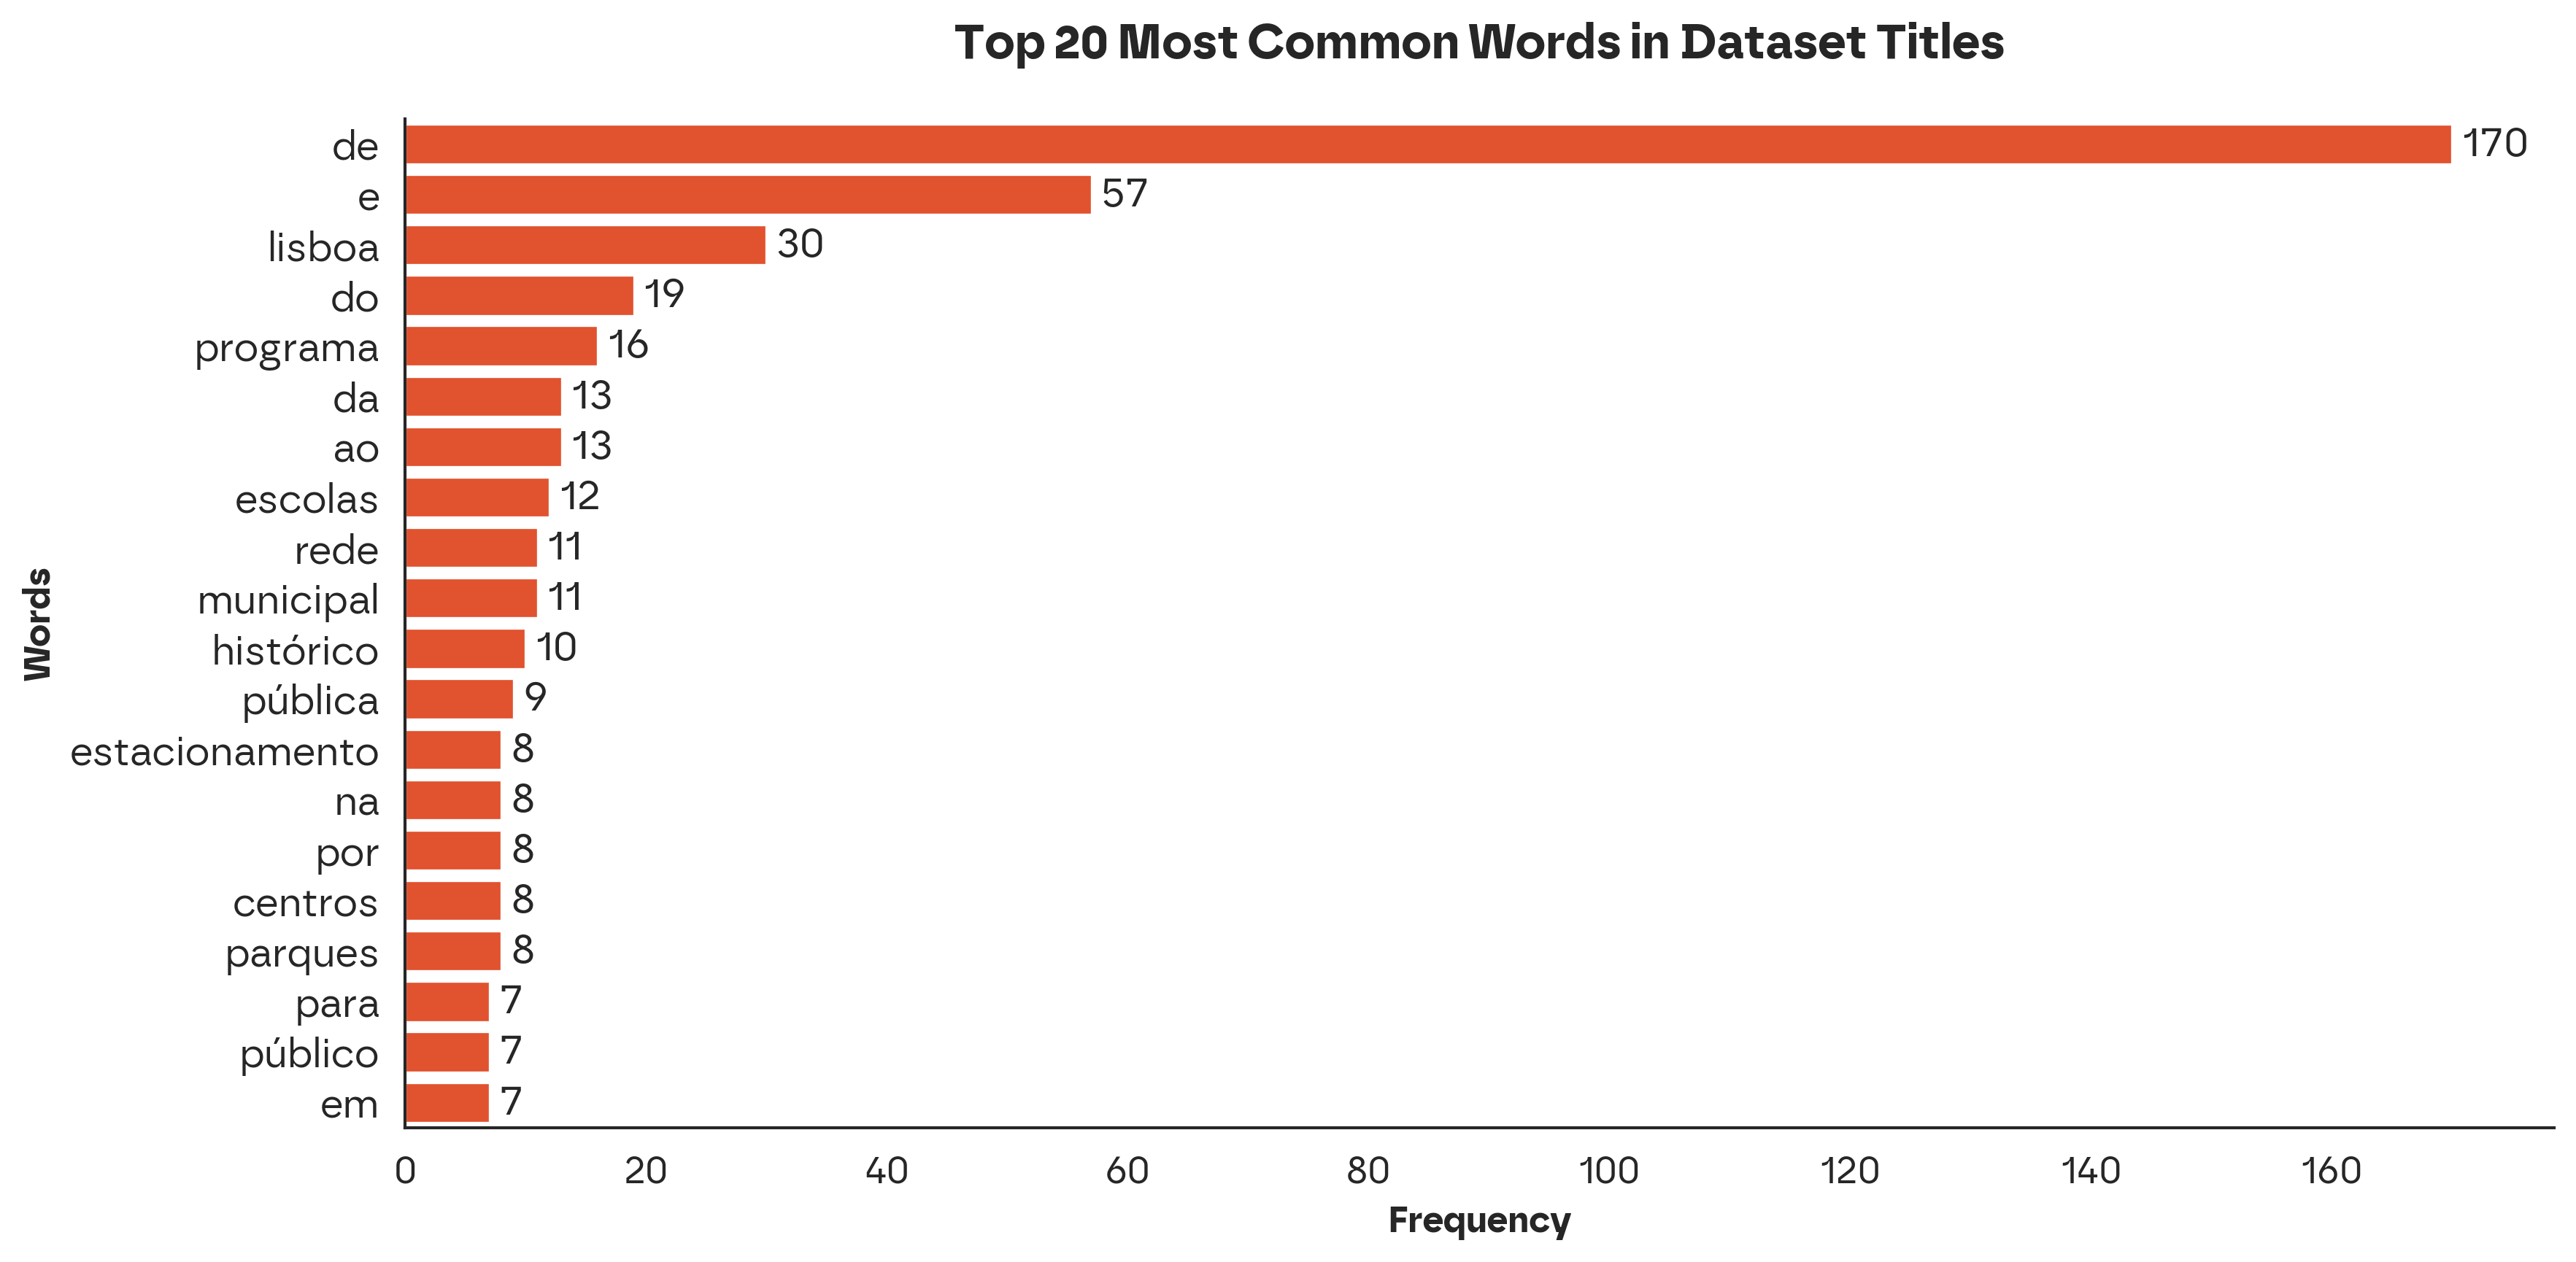

In [24]:
# Function to clean and tokenize text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.split()

# Analyze titles
all_titles = " ".join(df_lisbon['title'].astype(str))
title_words = clean_text(all_titles)
title_word_counts = Counter(title_words)

# Prepare data for plotting
top_words_df = pd.DataFrame(title_word_counts.most_common(20), columns=['Word', 'Count'])

# Plot Top 20 Most Common Words
plt.figure(figsize=(12, 6), dpi=300)
ax = sns.barplot(data=top_words_df, x='Count', y='Word', color=custom_palette[0])

# Customization
ax.set_title('Top 20 Most Common Words in Dataset Titles', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
ax.set_ylabel('Words', fontsize=12, fontweight='bold')
sns.despine(top=True, right=True)

# Add value labels to the bars
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.tight_layout()
plt.show()

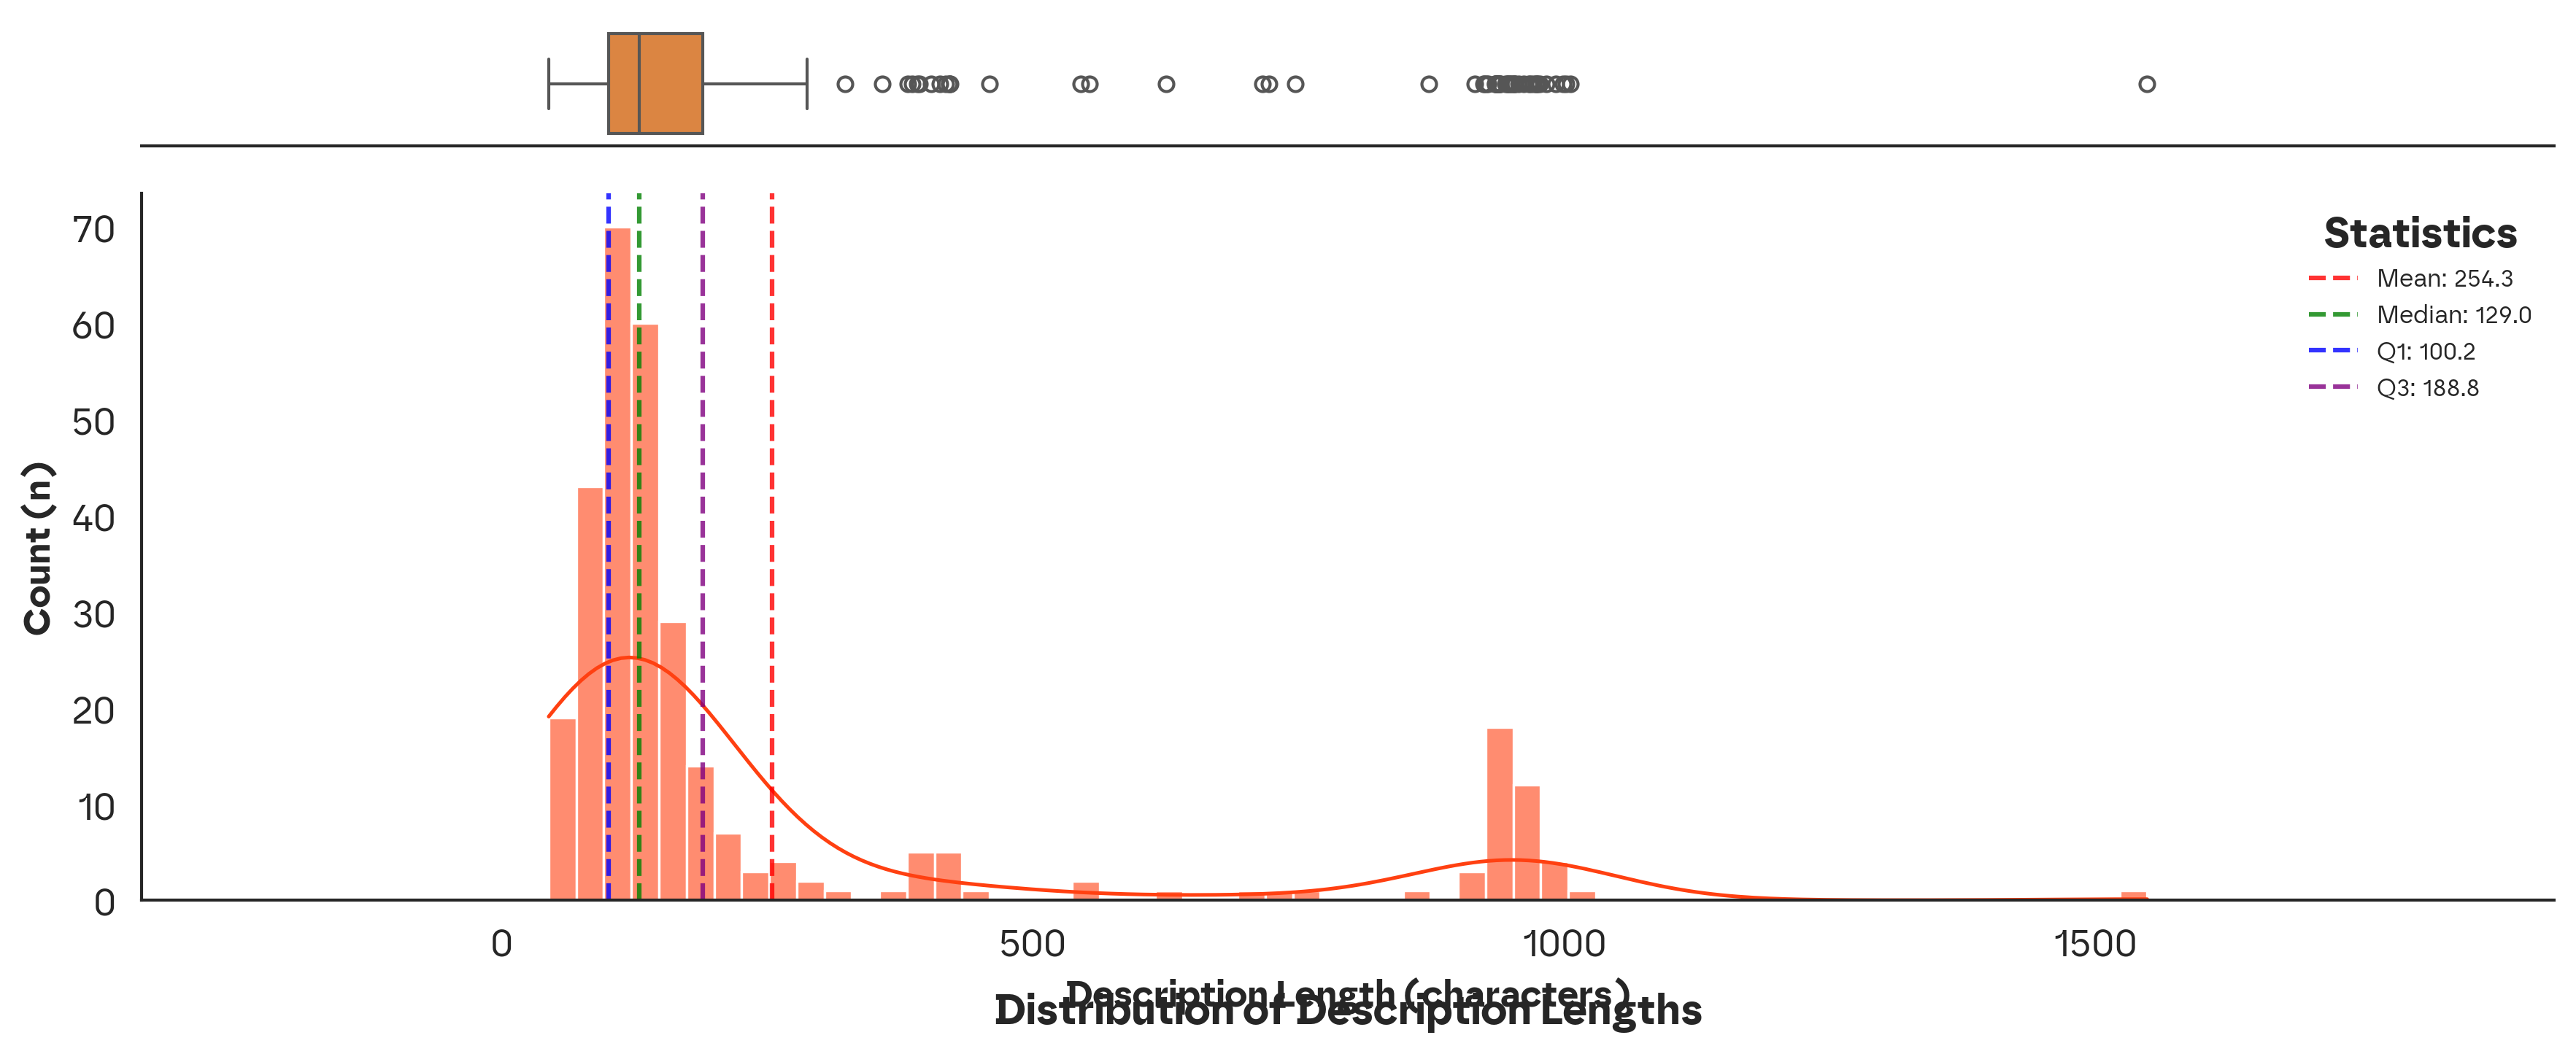

Datasets with the longest descriptions:


,title,description_length
2,Rede de monitorização e de alerta meteorológic...,1549
272,Comercialização de Hardware e Software e Serviços,1006
295,"Artes Performativas - Teatro, Dança e Música",1002
256,Ensino de Atividades Criativas e Culturais,999
260,"Edição (Livros, Jornais e Revistas)",992


In [23]:
# Analyze description length
df_lisbon['description_length'] = df_lisbon['description'].astype(str).apply(len)

# Prepare figure for Histogram & Boxplot
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(12, 5), dpi=300,
                                      sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

# Plot the Boxplot on the top
sns.boxplot(x=df_lisbon['description_length'], color=custom_palette[1], ax=ax_box)

# Plot the Histogram and the KDE on the bottom
sns.histplot(df_lisbon['description_length'], color=custom_palette[0], kde=True, stat='count', alpha=0.6, ax=ax_hist)
sns.kdeplot(df_lisbon['description_length'], color=custom_palette[0], lw=1, warn_singular=False, ax=ax_hist)

# Add mean, median and percentiles to the plot
mean_val = df_lisbon['description_length'].mean()
median_val = df_lisbon['description_length'].median()
q1_val = df_lisbon['description_length'].quantile(0.25)
q3_val = df_lisbon['description_length'].quantile(0.75)

ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Mean: {mean_val:.1f}')
ax_hist.axvline(median_val, color='green', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Median: {median_val:.1f}')
ax_hist.axvline(q1_val, color='blue', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Q1: {q1_val:.1f}')
ax_hist.axvline(q3_val, color='purple', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Q3: {q3_val:.1f}')

# Add a legend to the histogram
ax_hist.legend(loc='best', title='Statistics', title_fontproperties={'weight':'bold', 'size':'14'}, fontsize=8, frameon=False)

# Customizing the titles and labels
ax_box.set(xlabel='')
ax_hist.set_title('Distribution of Description Lengths', y=-0.2, fontweight='bold', fontsize=14)
ax_hist.set_xlabel('Description Length (characters)', fontsize=12, fontweight='bold')
ax_hist.set_ylabel('Count (n)', fontsize=12, fontweight='bold')

# Remove spines
sns.despine(ax=ax_box, left=True)
sns.despine(ax=ax_hist)
plt.tight_layout()
plt.show()

# Show datasets with the longest descriptions
print("\033[1mDatasets with the longest descriptions:\033[0m")
df_lisbon.nlargest(5, 'description_length')[['title', 'description_length']]

In [10]:
# Analyze file formats
all_formats = df_lisbon['file_formats'].dropna().explode()
format_counts = all_formats.value_counts()

# DataFrame with 'n' and '%'
format_df = pd.DataFrame({
    'n': format_counts,
    '%': (format_counts / len(df_lisbon) * 100).round(2)
})
format_df

,n,%
file_formats,,
geojson,179,57.74
xlsx,43,13.87
"geojson, json-ld",16,5.16
xls,7,2.26
geojason,6,1.94
csv,5,1.61
"csv, xlsx",5,1.61
shp,5,1.61
zip,4,1.29


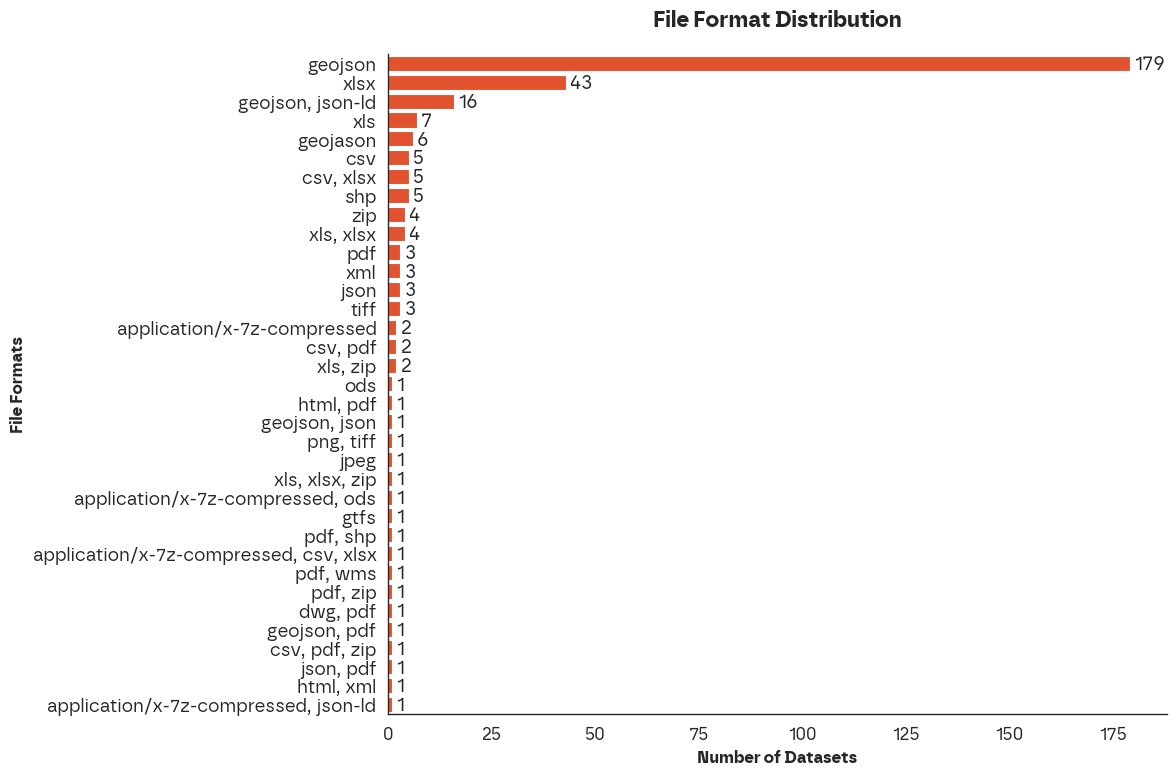

In [11]:
# Plot File Format Distribution
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=format_counts.values, y=format_counts.index, color=custom_palette[0])

# Customization
ax.set_title('File Format Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Datasets', fontsize=12, fontweight='bold')
ax.set_ylabel('File Formats', fontsize=12, fontweight='bold')
sns.despine(top=True, right=True)

# Add value labels to the bars
for i in ax.containers:
    ax.bar_label(i, padding=3)
    
plt.tight_layout()
plt.show()

### **Clean Dataset**

In [12]:
# Create a DataFrame for Lisbon Open Data (Clean)
df_lisbon_clean = pd.DataFrame(lisbon_datasets_clean)

# Display the first few rows
df_lisbon_clean.head()

,title,url_portal,stable_url,description,file_formats,last_updated
0,Lisboa. Pontos de encontro - Emergência.,https://dados.gov.pt/pt/datasets/plano-municip...,https://dados.gov.pt/pt/datasets/r/1df28fd3-9c...,Serviço de mapa com indicação da localização d...,geojson,2025-10-30T00:00:00
1,Zonas de Emissões Reduzidas,https://dados.gov.pt/pt/datasets/zonas-de-emis...,https://dados.gov.pt/pt/datasets/r/20eadc61-b4...,Serviço de mapa com indicação das principais e...,geojson,2025-10-30T00:00:00
2,Rede Ferroviária Subterrânea,https://dados.gov.pt/pt/datasets/https-geodado...,https://dados.gov.pt/pt/datasets/r/cc9157a3-e7...,Serviço de cartografia base. Lisbon Basemap.,geojson,2025-11-04T00:00:00
3,Rede LoRa,https://dados.gov.pt/pt/datasets/rede-lora/,https://dados.gov.pt/pt/datasets/r/4416a5ad-a5...,Serviço de mapas com a localização geográfica ...,geojson,2025-02-21T00:00:00
4,Sitios de interesse público,https://dados.gov.pt/pt/datasets/https-geodado...,https://dados.gov.pt/pt/datasets/r/6b6ed8be-c0...,"Conjunto de dados relativos a ""Sítios de inter...",geojson,2025-02-24T00:00:00


In [13]:
# Analyze file formats
all_formats = df_lisbon_clean['file_formats'].dropna().explode()
format_counts = all_formats.value_counts()

# DataFrame with 'n' and '%'
format_df = pd.DataFrame({
    'n': format_counts,
    '%': (format_counts / len(df_lisbon_clean) * 100).round(2)
})
format_df

,n,%
file_formats,,
geojson,156,92.31
"geojson, json-ld",12,7.10
json,1,0.59


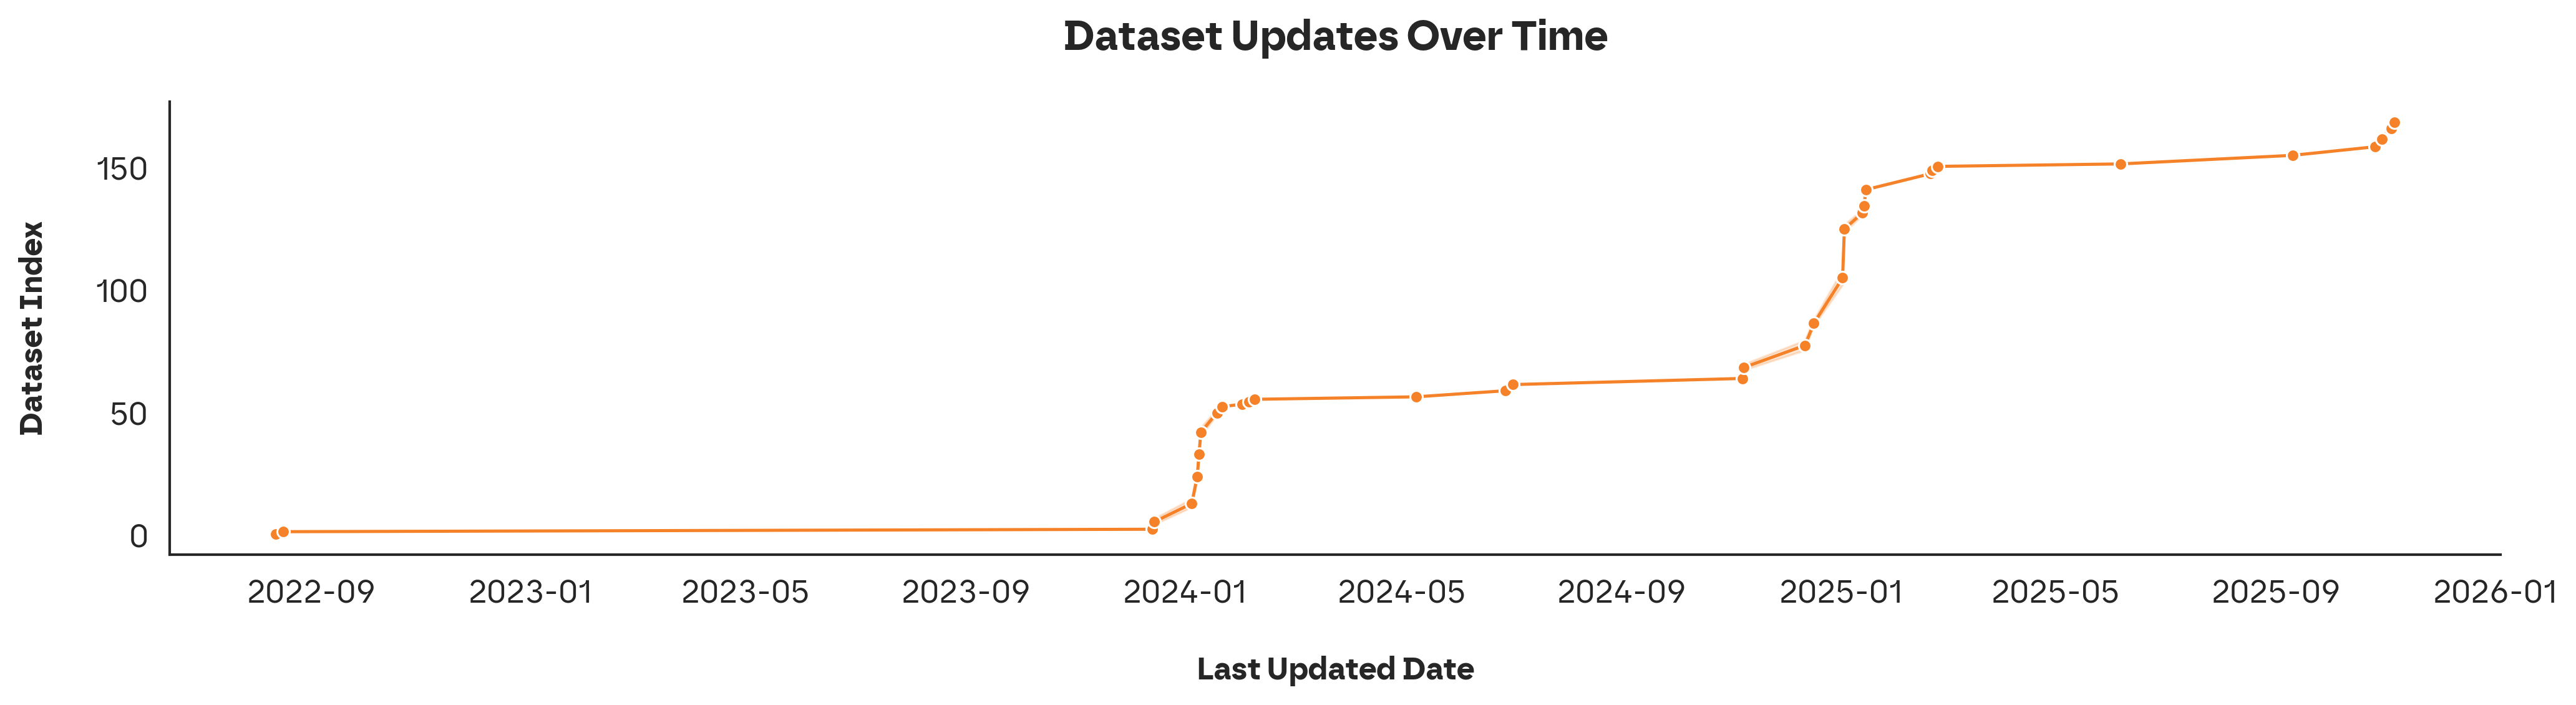

In [14]:
# Analyze last_updated dates
df_lisbon_clean['last_updated'] = pd.to_datetime(df_lisbon_clean['last_updated'], errors='coerce')

# Plot the time series of dataset updates
plt.figure(figsize=(14, 4), dpi=300)
sns.lineplot(data=df_lisbon_clean.sort_values('last_updated'), x='last_updated', y=df_lisbon_clean.index, marker='o', color=custom_palette[1])

# Customization
plt.title('Dataset Updates Over Time', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('\nLast Updated Date', fontsize=12, fontweight='bold')
plt.ylabel('Dataset Index\n', fontsize=12, fontweight='bold')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

In [15]:
# Code to test if all stable_url are reachable and return valid GeoJSON
import requests
import json
from typing import Dict, Any, Optional

def fetch_geojson(url: str, timeout: int = 15) -> Optional[Dict[str, Any]]:
    """
    Fetches and validates a GeoJSON from a URL.
    
    Args:
        url (str): URL to fetch GeoJSON from.
        timeout (int): Request timeout in seconds.
        
    Returns:
        Optional[Dict]: GeoJSON data if valid, None otherwise.
    """
    try:
        response = requests.get(url, timeout=timeout)
        response.raise_for_status()
        
        # Try to parse as JSON
        data = response.json()
        
        # Validate GeoJSON structure
        if isinstance(data, dict) and "type" in data:
            valid_types = ["FeatureCollection", "Feature", "Point", "LineString", 
                          "Polygon", "MultiPoint", "MultiLineString", "MultiPolygon"]
            if data["type"] in valid_types:
                return data
        
        return None
        
    except (requests.RequestException, json.JSONDecodeError) as e:
        print(f"Error: {e}")
        return None

# Test all stable URLs
print("\033[1mTesting GeoJSON URLs (15s timeout)...\033[0m\n")
results = {"success": 0, "failed": 0, "not_geojson": 0}

for idx, row in tqdm(df_lisbon_clean.iterrows(), total=len(df_lisbon_clean), desc="Checking GeoJSON URLs"):
    url = row['stable_url']
    title = row['title']
    
    # print(f"\033[1m[{idx+1}/{len(df_lisbon_clean)}]\033[0m {title[:60]}...")
    
    geojson_data = fetch_geojson(url)
    
    if geojson_data:
        # For debugging
        # feature_count = len(geojson_data.get('features', []))
        # print(f"  \033[1;32m✅ Valid GeoJSON\033[0m - {feature_count} features")
        results["success"] += 1
    else:
        print(f"\033[1m[{idx+1}/{len(df_lisbon_clean)}]\033[0m {title[:60]}...")
        print(f"  \033[1;31m❌ Failed or invalid GeoJSON\033[0m", url)
        results["failed"] += 1
        print()

# Summary
print("\n" + "="*60)
print("\033[1mSummary:\033[0m")
print(f"  \033[1;32m✅ Success:\033[0m {results['success']}")
print(f"  \033[1;31m❌ Failed:\033[0m {results['failed']}")
print(f"  \033[1m  Total:\033[0m {len(df_lisbon_clean)}")
print("="*60)

Testing GeoJSON URLs (15s timeout)...



Checking GeoJSON URLs:   9%|▉         | 16/169 [00:18<02:27,  1.04it/s]

Error: 403 Client Error: Forbidden for url: https://www.agendalx.pt/wp-json/agendalx/v1/events
[16/169] Agenda Cultural de Lisboa...
  ❌ Failed or invalid GeoJSON https://www.agendalx.pt/wp-json/agendalx/v1/events



Checking GeoJSON URLs: 100%|██████████| 169/169 [03:00<00:00,  1.07s/it]


Summary:
  ✅ Success: 168
  ❌ Failed: 1
    Total: 169


In [16]:
# Example: Agent tool for dynamic GeoJSON fetching
#          This simulates what the agent will do when it needs geospatial data

def agent_fetch_geojson(title_keyword: str, timeout: int = 15):
    """
    Simulates how the agent will fetch GeoJSON data dynamically.
    
    Args:
        title_keyword (str): Keyword to search in dataset titles.
        timeout (int): Request timeout in seconds.
        
    Returns:
        dict: GeoJSON data or error information.
    """
    import time
    
    # Search for dataset
    matches = df_lisbon_clean[
        df_lisbon_clean['title'].str.contains(title_keyword, case=False, na=False)
    ]
    
    if matches.empty:
        return {"error": f"No dataset found for: {title_keyword}"}
    
    dataset = matches.iloc[0]
    url = dataset['stable_url']
    title = dataset['title']
    
    print(f"\033[1m🔍 Searching for:\033[0m {title_keyword}")
    print(f"\033[1m✅ Found:\033[0m {title}")
    print(f"\033[1m🌐 URL:\033[0m {url}")
    print(f"\033[1m⏱️ Fetching with {timeout}s timeout...\033[0m\n")
    
    start_time = time.time()
    
    # Fetch GeoJSON
    geojson = fetch_geojson(url, timeout=timeout)
    
    elapsed = time.time() - start_time
    
    if geojson:
        feature_count = len(geojson.get('features', []))
        print(f"\033[1;32m✅ Success!\033[0m")
        print(f"  ⏱️ Time: {elapsed:.2f}s")
        print(f"  📊 Features: {feature_count}")
        print(f"  📦 Type: {geojson.get('type')}")
        return geojson
    else:
        print(f"\033[1;31m❌ Failed after {elapsed:.2f}s\033[0m")
        return {"error": "Failed to fetch or invalid GeoJSON"}

# Test 1: Fetch Metro stations
print("="*70)
print("\033[1mTest 1: Metro Stations\033[0m")
print("="*70)
metro_data = agent_fetch_geojson("metro")

if metro_data and 'features' in metro_data:
    print(f"\n\033[1mFirst station:\033[0m")
    first_station = metro_data['features'][0]
    print(f"  Name: {first_station['properties'].get('NOME', 'N/A')}")
    print(f"  Line: {first_station['properties'].get('LINHA', 'N/A')}")
    print(f"  Coordinates: {first_station['geometry']['coordinates']}")

print("\n" + "="*70 + "\n")

Test 1: Metro Stations
🔍 Searching for: metro
✅ Found: Estações de Metro
🌐 URL: https://services.arcgis.com/1dSrzEWVQn5kHHyK/arcgis/rest/services/POITransportes/FeatureServer/1/query?outFields=*&where=1%3D1&f=geojson
⏱️ Fetching with 15s timeout...

✅ Success!
  ⏱️ Time: 0.61s
  📊 Features: 50
  📦 Type: FeatureCollection

First station:
  Name: Cais do Sodré
  Line: Verde
  Coordinates: [-9.14620795021712, 38.7061150810876]




## <span style="color: #ffffff;">Visit Lisbon Analysis</span>
<style>
@import url('https://fonts.cdnfonts.com/css/avenir-next-lt-pro?styles=29974');
</style>

<div style="background: transparent;
            padding: 10px; color: white; border-radius: 300px; text-align: center;
            border: 2px solid #FFCD41;">
    <center><h2 style="margin-left: 120px;margin-top: 10px; margin-bottom: 4px; color: #FFCD41;
                       font-size: 24px; font-family: 'Avenir Next LT Pro', sans-serif;"><b> Visit Lisbon Analysis</b></h2></center>
</div>

<br>

This section analyzes the datasets scraped from the **[Visit Lisbon](https://www.visitlisboa.com/)** website.


### **🔎 Dataset Attributes**

<center><b>Table 2 | </b> Dataset Attributes with Descriptions (Visit Lisbon). <br>

<br>

|       | **Field**                          | **Description**                                                                 | **Type**     |
|:-----:|:----------------------------------:|---------------------------------------------------------------------------------|:------------:|
| **1** | `url`                              | URL of the event or place                                                        | **`Text`**         |
| **2** | `category`                         | Category classification of the event or place                                   | **`Categorical`**  |
| **3** | `image_urls`                       | List of image URLs associated with the event or place                           | **`List`**         |
| **4** | `video_urls`                       | List of video URLs associated with the event or place                           | **`List`**         |
| **5** | `full_description`                 | Detailed description of the event or place                                      | **`Text`**         |
| **6** | `dates`                            | Dates related to the event (only in `events.json`)                              | **`List`**         |
| **7** | `information_links`                | Additional information links for the event                                      | **`Object`**       |
| **8** | `title`                            | Title of the place (only in places.json)                                        | **`Text`**         |
| **9** | `short_description`                | Short description of the place (only in places.json)                            | **`Text`**         |
| **10**| `features`                         | List of features of the place (only in places.json)                             | **`List`**         |
| **11**| `contact_info`                     | Contact information for the place (only in places.json)                         | **`Object`**       |
| **12**| `social_media`                     | Social media links for the place (only in places.json)                          | **`Object`**       |
| **13**| `schedule`                         | Operating schedule for the place (only in places.json)                          | **`Object`**       |
| **14**| `location`                         | Location details of the place (only in places.json)                             | **`Text`**         |
| **15**| `tripadvisor`                      | TripAdvisor information for the place (only in places.json)                     | **`Object`**       |

</center>

</center>

In [17]:
# Convert 'visitlisbon_events' and 'visitlisbon_places' JSON data to DataFrames
events_df = pd.DataFrame(events_data)
places_df = pd.DataFrame(places_data)

In [ ]:
# Count the number of observations in each file
num_events = len(events_df)
num_places = len(places_df)

print(f"\033[1mNumber of observations in events.json:\033[0m {num_events}")
print(f"\033[1mNumber of observations in places.json:\033[0m {num_places}")

Number of observations in events.json: 149
Number of observations in places.json: 1171


In [19]:
# Frequency table for events.json categories
events_freq = events_df['category'].value_counts().reset_index()
events_freq.columns = ['Category', 'n']
events_freq['%'] = (events_freq['n'] / events_freq['n'].sum() * 100).round(2)

print("\033[1mFrequency table for events.json:\033[0m")
events_freq.set_index('Category')

Frequency table for events.json:


,n,%
Category,,
Exhibitions,47,31.97
Main Events,33,22.45
Music,24,16.33
Fairs,14,9.52
Theater Opera & Dance,13,8.84
Festivals,7,4.76
Others,5,3.40
Cinema,3,2.04
Sports,1,0.68


In [20]:
# Frequency table for places.json categories
places_freq = places_df['category'].value_counts().reset_index()
places_freq.columns = ['Category', 'n']
places_freq['%'] = (places_freq['n'] / places_freq['n'].sum() * 100).round(2)

print("\033[1mFrequency table for places.json:\033[0m")
places_freq.set_index('Category')

Frequency table for places.json:


,n,%
Category,,
Hotel,224,22.58
Tours,116,11.69
Restaurant,114,11.49
Museums,68,6.85
Monuments,61,6.15
Museums & Monuments,45,4.54
Apartments & Hotel Apartments,34,3.43
DMCS & PCOS,31,3.12
Shopping,30,3.02


In [25]:
# Combined frequency table
events_freq['Source'] = 'Events'
places_freq['Source'] = 'Places'
combined_freq = pd.concat([events_freq, places_freq])
combined_freq = combined_freq.groupby('Category')['n'].sum().reset_index()
combined_freq['%'] = (combined_freq['n'] / combined_freq['n'].sum() * 100).round(2)
combined_freq = combined_freq.sort_values('n', ascending=False)

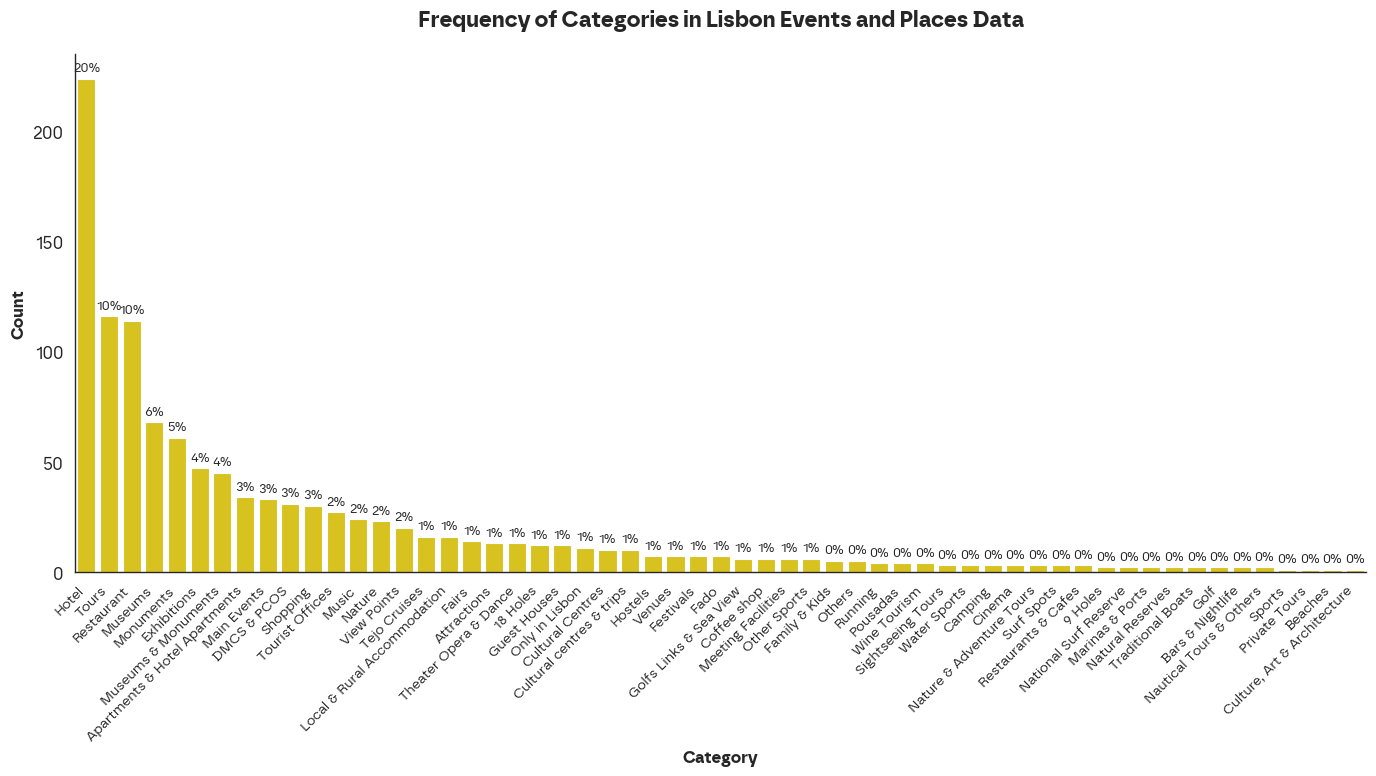

In [29]:
# Create a bar chart in yellow tones for Lisbon categories
plt.figure(figsize=(14, 8))

# Create barplot
ax = sns.barplot(data=combined_freq, x='Category', y='n', color=custom_palette[2])

# Customization
ax.set_title('Frequency of Categories in Lisbon Events and Places Data', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add % labels
for i in ax.containers:
    ax.bar_label(i, labels=[f'{p:.0f}%' for p in combined_freq['%']], padding=3, fontsize=10)

# Remove spines
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()